Starting ANN Time-Series Cross-Validation...


C:\Users\W11\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 completed: R²=0.8920, NMSE=0.0074, NMAE=0.0546


C:\Users\W11\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 completed: R²=0.9723, NMSE=0.0014, NMAE=0.0193


...

Fold 3 completed: R²=0.7634, NMSE=0.0138, NMAE=0.1004


C:\Users\W11\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 completed: R²=0.9269, NMSE=0.0050, NMAE=0.0482


C:\Users\W11\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 completed: R²=0.7521, NMSE=0.0135, NMAE=0.1093

=========== ANN TIME-SERIES CV RESULTS ===========
NMAE : 0.0664 ± 0.0337
NMSE : 0.0082 ± 0.0048
R²   : 0.8613 ± 0.0884
MAPE : 73.42% ± 41.25%

========== DIEBOLD-MARIANO TEST RESULT ==========
Comparison : ANN Prediction vs. Naive Baseline (Lag 12)
DM Stat    : -2.5311
p-value    : 0.0114


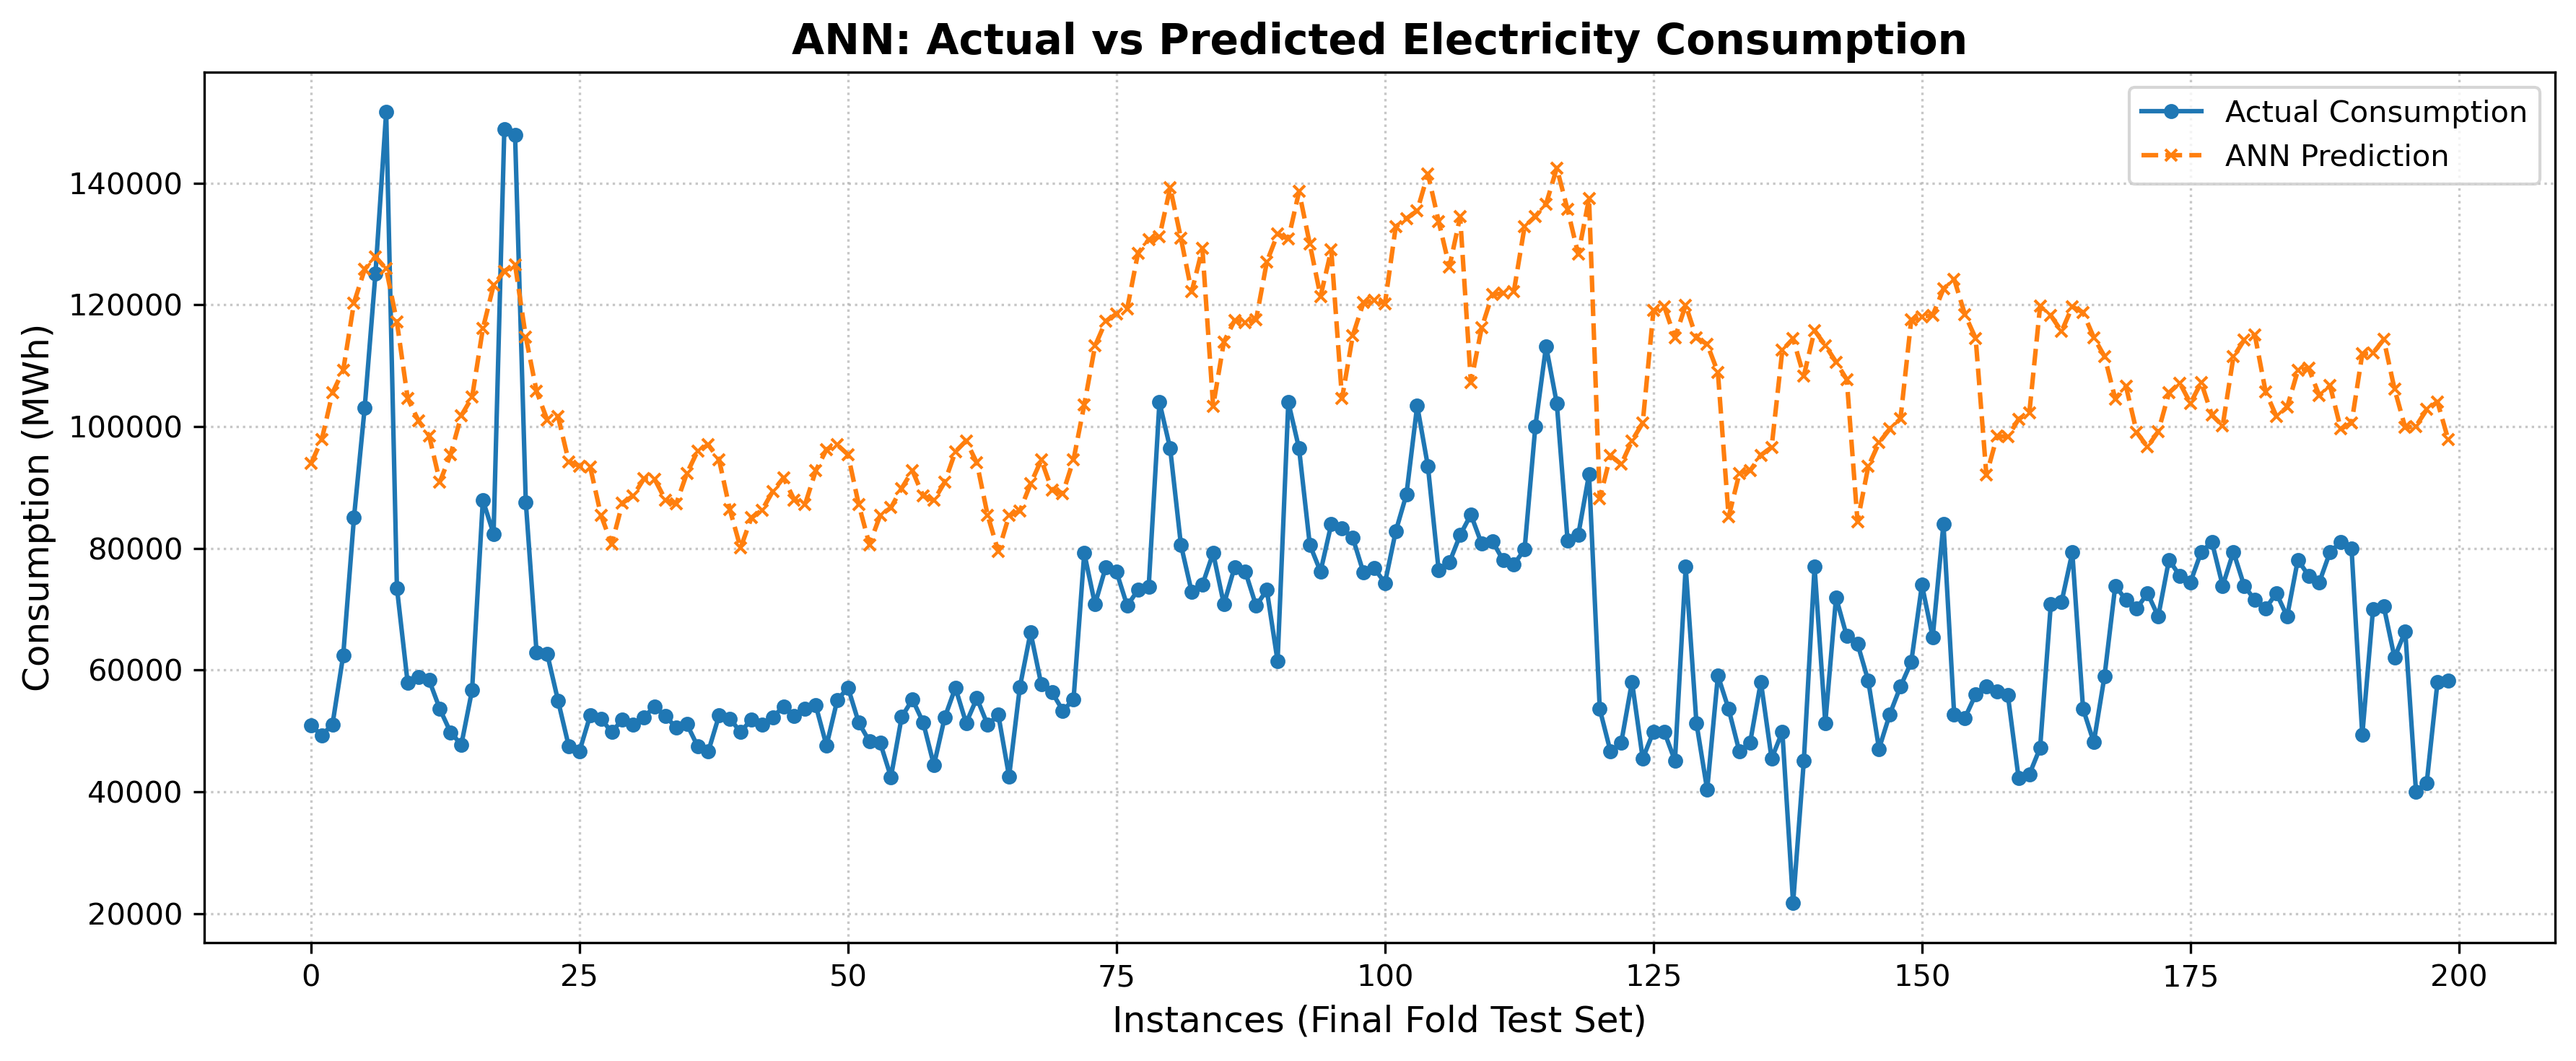

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# 1) DIEBOLD-MARIANO TEST FUNCTION
# ---------------------------------------------------------
def diebold_mariano(y_true, y_pred1, y_pred2):
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2
    d = e1**2 - e2**2
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

def main():
    # ---------------------------------------------------------
    # 2) DATA LOADING
    # ---------------------------------------------------------
    OUTPUT_PATH = os.path.join("..", "..", "processed_data", "final", "ML_En.xlsx")
    df = pd.read_excel(OUTPUT_PATH)
    df["Plate"] = df["Plate"].astype(str).str.lower()
    df = df.sort_values(["Plate", "Year", "Month"]).reset_index(drop=True)

    # ---------------------------------------------------------
    # 3) LAG FEATURES
    # ---------------------------------------------------------
    lag = 12
    for l in range(1, lag + 1):
        df[f"lag_{l}"] = df.groupby("Plate")["Consumption"].shift(l)
    df = df.dropna().reset_index(drop=True)

    # ---------------------------------------------------------
    # 4) FEATURE ENGINEERING & TARGET
    # ---------------------------------------------------------
    features = ["Lighting", "Public", "Residential", "Industry", "Agriculture",
                "Population", "Month", "Season", "Region", "Latitude", "Longitude",
                "Daylight Duration", "Altitude"] + [f"lag_{i}" for i in range(1, lag + 1)]

    X = df[features].values
    y = df["Consumption"].values

    # ---------------------------------------------------------
    # 5) TIME SERIES CROSS-VALIDATION
    # ---------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=5)
    fold_metrics = []
    final_y_true, final_y_pred = None, None

    print("Starting ANN Time-Series Cross-Validation...")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        X_train = scaler_X.fit_transform(X_train)
        X_test  = scaler_X.transform(X_test)
        y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
        y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

        # ANN Yapısı
        model = Sequential([
            Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
            Dropout(0.2),
            Dense(64, activation="relu"),
            Dropout(0.2),
            Dense(32, activation="relu"),
            Dense(1)
        ])
        model.compile(optimizer="adam", loss="mse")
        es = EarlyStopping(patience=15, restore_best_weights=True)

        model.fit(X_train, y_train_s, validation_split=0.2, epochs=150, batch_size=64, callbacks=[es], verbose=0, shuffle=False)
        
        y_pred_s = model.predict(X_test, verbose=0).ravel()

        # Tahminleri ve gerçek değerleri orijinal (MWh) ölçeğine geri döndürüyoruz
        y_test_orig = y_test
        y_pred_orig = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

        # --- DÜZELTİLMİŞ METRİK HESAPLAMALARI (Orijinal Ölçekte) ---
        y_range = y_test_orig.max() - y_test_orig.min()
        y_range_safe = y_range if y_range != 0 else 1
        
        mse_val = mean_squared_error(y_test_orig, y_pred_orig)
        mae_val = mean_absolute_error(y_test_orig, y_pred_orig)
        
        # NMSE için paydanın karesi alındı
        nmse = mse_val / (y_range_safe ** 2)
        nmae = mae_val / y_range_safe
        r2   = r2_score(y_test_orig, y_pred_orig)
        mape = np.mean(np.abs((y_test_orig - y_pred_orig) / (np.abs(y_test_orig) + 1e-10))) * 100

        fold_metrics.append([r2, nmse, nmae, mape])
        print(f"Fold {fold} completed: R²={r2:.4f}, NMSE={nmse:.4f}, NMAE={nmae:.4f}")

        if fold == tscv.n_splits:
            final_y_true = y_test_orig
            final_y_pred = y_pred_orig

    # ---------------------------------------------------------
    # 6) FORMATLI METRİK ÇIKTILARI
    # ---------------------------------------------------------
    fold_metrics = np.array(fold_metrics)
    print("\n" + "="*45)
    print("=========== ANN TIME-SERIES CV RESULTS ===========")
    print("="*45)
    print(f"NMAE : {fold_metrics[:,2].mean():.4f} ± {fold_metrics[:,2].std():.4f}")
    print(f"NMSE : {fold_metrics[:,1].mean():.4f} ± {fold_metrics[:,1].std():.4f}")
    print(f"R²   : {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
    print(f"MAPE : {fold_metrics[:,3].mean():.2f}% ± {fold_metrics[:,3].std():.2f}%")
    print("="*45)

    # ---------------------------------------------------------
    # 7) DIEBOLD-MARIANO TEST (vs Naive)
    # ---------------------------------------------------------
    y_naive = pd.Series(final_y_true).shift(12).bfill().values
    dm_stat, p_value = diebold_mariano(final_y_true, final_y_pred, y_naive)
    print("\n" + "="*45)
    print("========== DIEBOLD-MARIANO TEST RESULT ==========")
    print("="*45)
    print(f"Comparison : ANN Prediction vs. Naive Baseline (Lag 12)")
    print(f"DM Stat    : {dm_stat:.4f}")
    print(f"p-value    : {p_value:.4f}")
    print("="*45)

    # ---------------------------------------------------------
    # 8) GRAFİK ÇİZİMİ
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 5), dpi=300)
    plot_limit = min(200, len(final_y_true))
    plt.plot(final_y_true[:plot_limit], label='Actual Consumption', color='#1f77b4', marker='o', markersize=4, linewidth=1.5)
    plt.plot(final_y_pred[:plot_limit], label='ANN Prediction', color='#ff7f0e', marker='x', markersize=4, linestyle='--', linewidth=1.5)
    plt.title("ANN: Actual vs Predicted Electricity Consumption", fontsize=14, fontweight='bold')
    plt.xlabel("Instances (Final Fold Test Set)", fontsize=12)
    plt.ylabel("Consumption (MWh)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.savefig("ann_n_metrics_plot.png")
    plt.show()

if __name__ == "__main__":
    main()